In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [42]:
# DANE 2023

In [43]:
print("Wczytywanie danych")
df_dl_2023 = pd.read_csv(r'C:\Users\mikol\Desktop\PAMSI\Projekt1\data-raw-2023-feb\202302\curr_httpgetmt.csv')
df_ul_2023 = pd.read_csv(r'C:\Users\mikol\Desktop\PAMSI\Projekt1\data-raw-2023-feb\202302\curr_httppostmt.csv')

Wczytywanie danych


In [44]:
# Wyświetlenie początkowych wierszy
print(df_dl_2023.head())
print(df_ul_2023.head())

   unit_id                dtime                          target       address  \
0      386  2023-02-02 11:46:44  sp1-vm-newyork-us.samknows.com  151.139.31.1   
1      386  2023-02-02 17:46:29  sp1-vm-newyork-us.samknows.com  151.139.31.1   
2      386  2023-02-04 01:51:30  sp1-vm-newyork-us.samknows.com  151.139.31.1   
3      386  2023-02-05 17:47:10  sp2-vm-newyork-us.samknows.com  151.139.31.8   
4      386  2023-02-06 17:49:28  sp1-vm-newyork-us.samknows.com  151.139.31.1   

   fetch_time  bytes_total  bytes_sec  bytes_sec_interval  warmup_time  \
0    10028665    257012514   25627789            25627789      5028092   
1    10018544    255021762   25454972            25454972      1523612   
2    10046837    250815180   24964591            24964591      5016757   
3    10016105    258943152   25852679            25852679      5008756   
4    10028916    250831956   25010874            25010874      5019601   

   warmup_bytes  sequence  threads  successes  failures  
0     1220

In [45]:
# Selekcja kolumn
# unit_id - id użytkownika
# bytes_sec - średnia prędkość transferu
# dtime - data
cols_to_keep = ['unit_id', 'bytes_sec', 'dtime']
df_dl_2023 = df_dl_2023[cols_to_keep]
df_ul_2023 = df_ul_2023[cols_to_keep]

In [46]:
# Przeliczamy bajty/s na Megabity/s
# (bytes_sec * 8 / 1024 / 1024)
df_dl_2023['download_mbps'] = (df_dl_2023['bytes_sec'] * 8) / (1024 * 1024)
df_ul_2023['upload_mbps'] = (df_ul_2023['bytes_sec'] * 8) / (1024 * 1024)

In [47]:
# Agregacja danych
# Ponieważ każdy użytkownik (unit_id) wykonuje wiele testów, 
# wyciągamy średnią prędkość dla każdego z nich.
print("Agregowanie danych tych samych użytkowników")
df_dl_2023_avg = df_dl_2023.groupby('unit_id')['download_mbps'].mean().reset_index()
df_ul_2023_avg = df_ul_2023.groupby('unit_id')['upload_mbps'].mean().reset_index()

Agregowanie danych tych samych użytkowników


In [48]:
# Łączymy download i upload w jedną tabelę po unit_id
df_final_2023 = pd.merge(df_dl_2023_avg, df_ul_2023_avg, on='unit_id', how='inner')
print(f"Połączono dane dla {len(df_final_2023)} użytkowników.")
print(df_final_2023.head())

Połączono dane dla 4297 użytkowników.
   unit_id  download_mbps  upload_mbps
0      386     185.786548   150.929777
1      390      89.238678    89.492425
2      422     173.843533     5.622417
3      431      76.809517    89.556298
4      447      77.110546    84.489954


Wykres zależności został zapisany.


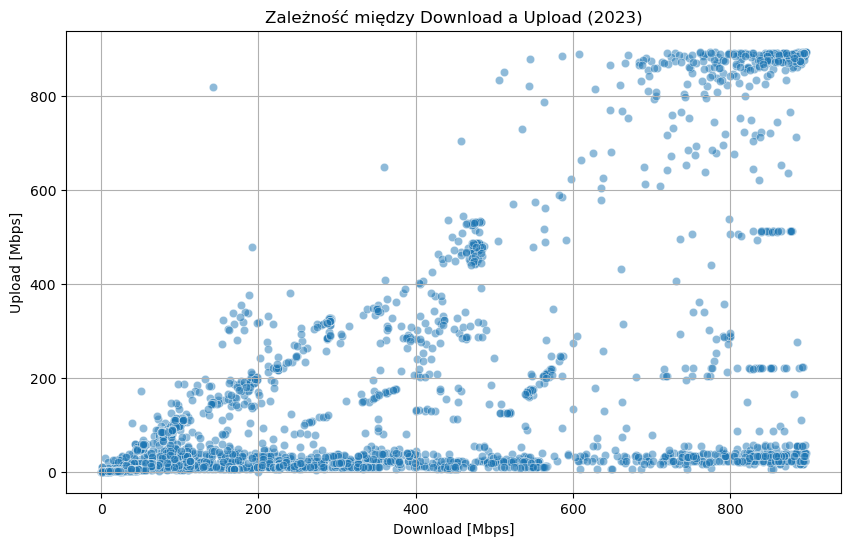

In [49]:
# Wykres zależności Upload od Download
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_final_2023, x='download_mbps', y='upload_mbps', alpha=0.5)
plt.title('Zależność między Download a Upload (2023)')
plt.xlabel('Download [Mbps]')
plt.ylabel('Upload [Mbps]')
plt.grid(True)
plt.savefig('zaleznosc_dl_ul.png')
print("Wykres zależności został zapisany.")

In [50]:
# DANE 2021

In [51]:
print("Wczytywanie danych")
df_dl_2021 = pd.read_csv(r'C:\Users\mikol\Desktop\PAMSI\Projekt1\data-raw-2021-feb\202102\curr_httpgetmt.csv')
df_ul_2021 = pd.read_csv(r'C:\Users\mikol\Desktop\PAMSI\Projekt1\data-raw-2021-feb\202102\curr_httppostmt.csv')

Wczytywanie danych


In [52]:
# Wyświetlenie początkowych wierszy
print(df_dl_2021.head())
print(df_ul_2021.head())

   unit_id                dtime                          target  \
0      386  2021-02-01 08:34:20  sp2-vm-newyork-us.samknows.com   
1      386  2021-02-01 14:35:59  sp2-vm-newyork-us.samknows.com   
2      386  2021-02-01 14:45:29     newyorkfcc.west.verizon.net   
3      390  2021-02-01 01:51:22  sp2-vm-newyork-us.samknows.com   
4      390  2021-02-01 03:51:19  sp2-vm-newyork-us.samknows.com   

          address  fetch_time  bytes_total  bytes_sec  bytes_sec_interval  \
0    151.139.31.8    10014585    220221348   21990062            21990062   
1    151.139.31.8    10013978    214999818   21469971            21469971   
2  206.124.86.197    10009155    198978368   19879637            19879637   
3    151.139.31.8    10033353    118023354   11763102            11763102   
4    151.139.31.8    10053968    116570832   11594510            11594510   

   warmup_time  warmup_bytes  sequence  threads  successes  failures  \
0      1509794      31294502         0        8          1    

In [53]:
# Selekcja kolumn
# unit_id - id użytkownika
# bytes_sec - średnia prędkość transferu
# dtime - data
cols_to_keep = ['unit_id', 'bytes_sec', 'dtime']
df_dl_2021 = df_dl_2021[cols_to_keep]
df_ul_2021 = df_ul_2021[cols_to_keep]

In [54]:
# Przeliczamy bajty/s na Megabity/s
# (bytes_sec * 8 / 1024 / 1024)
df_dl_2021['download_mbps'] = (df_dl_2021['bytes_sec'] * 8) / (1024 * 1024)
df_ul_2021['upload_mbps'] = (df_ul_2021['bytes_sec'] * 8) / (1024 * 1024)

In [55]:
# Agregacja danych
# Ponieważ każdy użytkownik (unit_id) wykonuje wiele testów, 
# wyciągamy średnią prędkość dla każdego z nich.
print("Agregowanie danych tych samych użytkowników")
df_dl_2021_avg = df_dl_2021.groupby('unit_id')['download_mbps'].mean().reset_index()
df_ul_2021_avg = df_ul_2021.groupby('unit_id')['upload_mbps'].mean().reset_index()

Agregowanie danych tych samych użytkowników


In [56]:
# Łączymy download i upload w jedną tabelę po unit_id
df_final_2021 = pd.merge(df_dl_2021_avg, df_ul_2021_avg, on='unit_id', how='inner')
print(f"Połączono dane dla {len(df_final_2021)} użytkowników.")
print(df_final_2021.head())

Połączono dane dla 5287 użytkowników.
   unit_id  download_mbps  upload_mbps
0        8      71.831611    88.405573
1      386     164.336290   139.052591
2      390      88.262947    88.739761
3      422     113.063085     5.651303
4      431      70.880217    87.076465


Wykres zależności został zapisany.


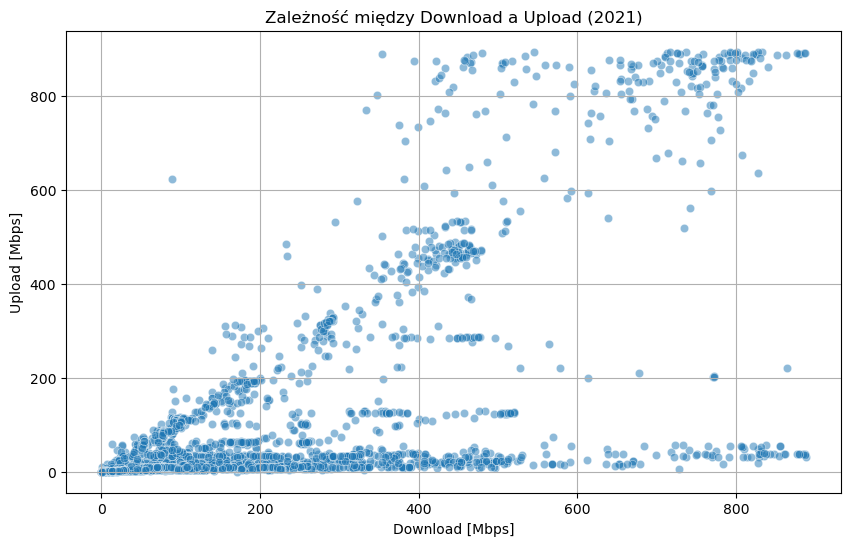

In [57]:
# Wykres zależności Upload od Download
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_final_2021, x='download_mbps', y='upload_mbps', alpha=0.5)
plt.title('Zależność między Download a Upload (2021)')
plt.xlabel('Download [Mbps]')
plt.ylabel('Upload [Mbps]')
plt.grid(True)
plt.savefig('zaleznosc_dl_ul_2021.png')
print("Wykres zależności został zapisany.")

     download_mbps                                          upload_mbps  \
              mean      median         std  min         max        mean   
year                                                                      
2021    139.807945   77.859075  177.780183  0.0  887.515589   66.484666   
2023    257.959499  110.316542  280.552072  0.0  896.142502  111.935316   

                                              
         median         std  min         max  
year                                          
2021   9.297471  168.362781  0.0  894.421747  
2023  16.510991  225.095799  0.0  894.307708  


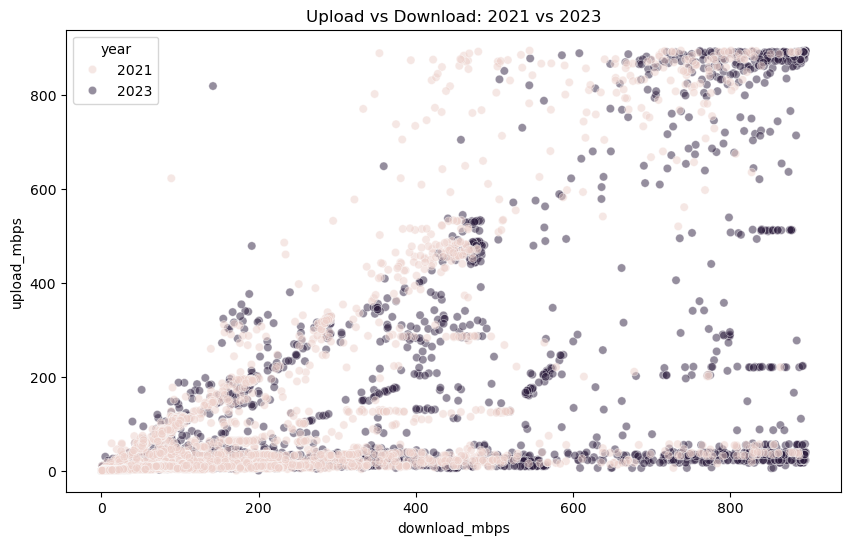

In [65]:
# Porównanie statystyk
df_final_2023['year'] = 2023
df_final_2021['year'] = 2021

comp = pd.concat([
    df_final_2023[['year', 'download_mbps', 'upload_mbps']],
    df_final_2021[['year', 'download_mbps', 'upload_mbps']]
], ignore_index=True)

print(comp.groupby('year').agg({
    'download_mbps': ['mean', 'median', 'std', 'min', 'max'],
    'upload_mbps': ['mean', 'median', 'std', 'min', 'max']
}))

# Dodatkowo scatter z porównaniem upload->download razem
plt.figure(figsize=(10,6))
sns.scatterplot(data=comp, x='download_mbps', y='upload_mbps', hue='year', alpha=0.5)
plt.title('Upload vs Download: 2021 vs 2023')
plt.show()

In [ ]:
# Porównanie statystyk
df_final_2023['year'] = 2023
df_final_2021['year'] = 2021

comp = pd.concat([
    df_final_2023[['year', 'download_mbps', 'upload_mbps']],
    df_final_2021[['year', 'download_mbps', 'upload_mbps']]
], ignore_index=True)

print(comp.groupby('year').agg({
    'download_mbps': ['mean', 'median', 'std', 'min', 'max'],
    'upload_mbps': ['mean', 'median', 'std', 'min', 'max']
}))

# Dodatkowo scatter z porównaniem upload->download razem
plt.figure(figsize=(10,6))
sns.scatterplot(data=comp, x='download_mbps', y='upload_mbps', hue='year', alpha=0.5)
plt.title('Upload vs Download: 2021 vs 2023')
plt.show()

In [59]:
# Zapisanie oczyszczonych danych do nowego pliku
#df_final.to_csv('dane_do_analizy_2023.csv', index=False)

In [60]:
# MODELOWANIE

In [61]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [62]:
# 1. Przygotowanie danych do modelowania
X = df_final[['upload_mbps']] # Cecha (feature)
y = df_final['download_mbps'] # Cel (target)

# Podział na zbiór treningowy (80%) i testowy (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Definicja i trenowanie modeli
models = {
    "Regresja Liniowa": LinearRegression(),
    "Drzewo Decyzyjne": DecisionTreeRegressor(max_depth=10, random_state=42),
    "Las Losowy (Random Forest)": RandomForestRegressor(n_estimators=100, random_state=42)
}

results = []

print("\nTrenowanie modeli i obliczanie metryk...")

for name, model in models.items():
    # Trenowanie
    model.fit(X_train, y_train)
    # Predykcja
    y_pred = model.predict(X_test)
    
    # Metryki
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results.append({"Model": name, "MAE": mae, "R2 Score": r2})

# 3. Prezentacja wyników w tabeli (Punkt 6 zadania)
df_results = pd.DataFrame(results)
print("\nPorównanie modeli:")
print(df_results)


Trenowanie modeli i obliczanie metryk...



Porównanie modeli:
                        Model         MAE  R2 Score
0            Regresja Liniowa  159.591673  0.456206
1            Drzewo Decyzyjne  102.461048  0.630786
2  Las Losowy (Random Forest)  106.561136  0.576545


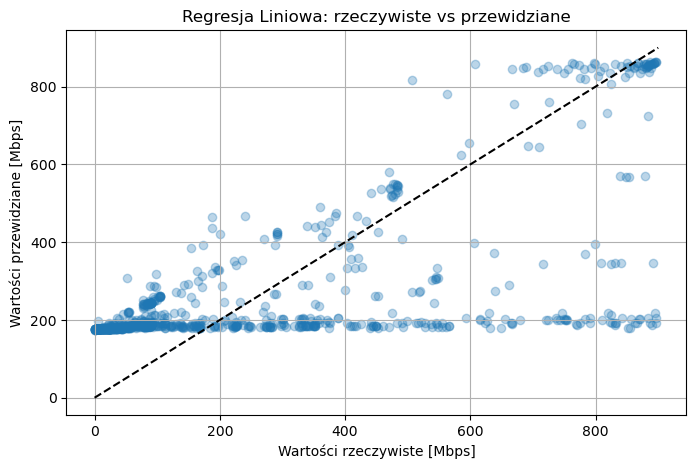

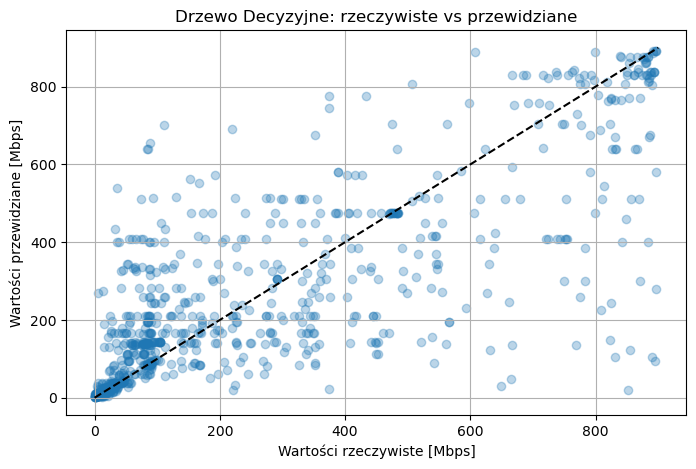

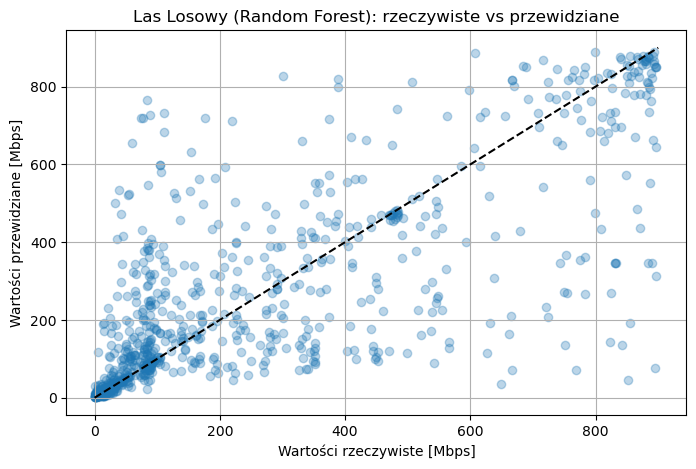

In [63]:
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    plt.figure(figsize=(8, 5))
    plt.scatter(y_test, y_pred, alpha=0.3)
    plt.plot([0, 900], [0, 900], '--k')
    plt.title(f"{name}: rzeczywiste vs przewidziane")
    plt.xlabel("Wartości rzeczywiste [Mbps]")
    plt.ylabel("Wartości przewidziane [Mbps]")
    plt.grid(True)
    plt.show()

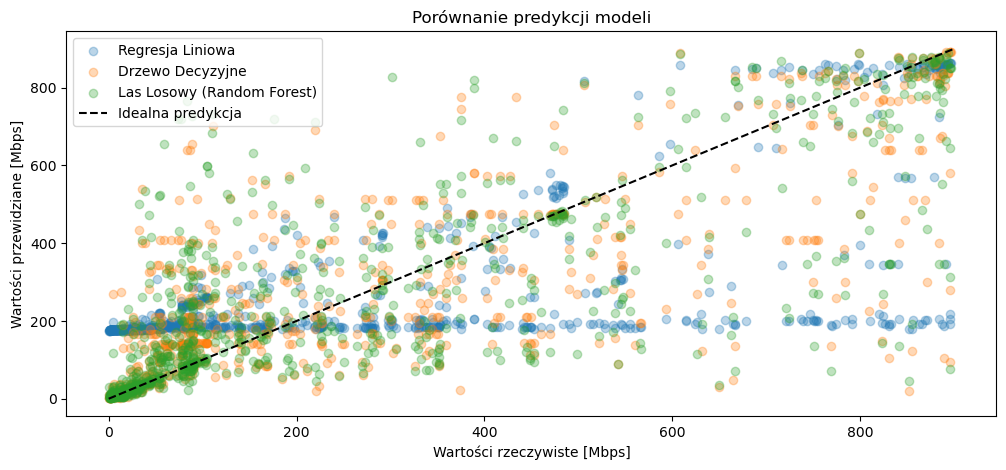

In [64]:
# 4. Wizualizacja predykcji
plt.figure(figsize=(12, 5))
for name, model in models.items():
    plt.scatter(y_test, model.predict(X_test), alpha=0.3, label=name)

plt.plot([0, 900], [0, 900], '--k', label="Idealna predykcja")
plt.xlabel("Wartości rzeczywiste [Mbps]")
plt.ylabel("Wartości przewidziane [Mbps]")
plt.title("Porównanie predykcji modeli")
plt.legend()
plt.show()